# Problem Set 3: Univariate Regressions

## 5 pts per question, 90 ptd in total. 

### Summary and Motivation

Problem Set 3 is designed to introduce students to the basics of regression analysis, a fundamental tool in data analytics and econometrics. By using the NLSY97 dataset, students will explore relationships between key variables such as education, gender, and hourly compensation. This problem set emphasizes practical experience with Python and the statsmodels library, reinforcing theoretical knowledge through hands-on data manipulation and analysis. 

### Instruction
The dataset data_NLSY97.xlsx, available on CANVAS, contains all necessary information. These data are sourced from
the NLSY97, a representative national database of individuals born in the early 1980s in the United States. Below are some variables we will use:

**Variables:**
- `educ`: Number of years of education completed
- `gender`: Denotes the gender of the individual
- `minority`: 1 if the individual belongs to a minority group, 0 otherwise
- `mother_educ`: 1 if the individual's mother has a college degree, 0 otherwise
- `annual_income`: Annual income from wages
- `gpa_in8`: GPA in 8th grade
- `retention`: 1 if the individual was required to repeat a grade during middle school, 0 otherwise


Please follow below questions and instructions to complete this problem set. In some questions, please write and execute Python code for data analysis in Cell mode. Comment your code to explain each step. Some questions need text discussion. Please Provide a detailed discussion of your results, including interpretations and answers to questions in Raw mode.

Once you have completed the assignment, save your Jupyter notebook with the following naming convention: `ECN310_ProblemSetX_LastName_FirstName.ipynb` (replace X with the assignment number).

---
### Exercise 0: Get Started (5 pts)

### Import Required Libraries and Dataset

**Best Practice:** Always import all libraries at the top of your notebook. This makes it easy to see dependencies and ensures all tools are available.

**Do NOT reload these libraries in this notebook again later.**

**Libraries we'll use:**
- `pandas`: For data manipulation and analysis
- `numpy`: For numerical operations
- `matplotlib.pyplot`: For creating visualizations
- `statsmodels.formula.api`: For regression analysis using formula notation



In [4]:
# Import all use libraries here and only once
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

### Exercise 1: Load and Explore the Dataset

This is the same database we used for our previous problem set. Each row contains information for each individual in the sample. (check the previous problem set for the definition of the variables).

**Coding Tips:**
- Use `pd.read_excel()` to load Excel files
- Store the data in a DataFrame (commonly named `df` or `data`)
- Make sure the file is in the same directory as your notebook, or provide the full path

1. Code that import the dataset. Do NOT reimport the dataset later.

In [10]:
# Load your dataset here and ONLY ONCE!
df=pd.read_excel("data_NLSY97.xlsx")
df.head()

,PUBID - YTH ID CODE 1997,educ,gpa_grade_8,retention,annual_income,total_weeks_exper,black,hispanic,white,mother_educ,minority,gender
0,1,16.0,3.0,0.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,female
1,2,14.0,3.5,0.0,115000.0,965.0,0.0,1.0,0.0,0.0,1.0,male
2,3,14.0,3.0,0.0,NaN,776.0,0.0,1.0,0.0,0.0,1.0,female
3,4,12.0,4.0,0.0,45000.0,1008.0,0.0,1.0,0.0,0.0,1.0,female
4,5,12.0,2.5,0.0,150000.0,890.0,0.0,1.0,0.0,0.0,1.0,male


2. Code that displays the dataset variables names and types and display first 10 rows.

- This helps you understand the structure of your data
- Check if the data looks reasonable (no obvious errors)

In [16]:
# Please write your executable code here - One-line code
print(df.columns)
print(df.dtypes)
print(df.head(10))

Index(['PUBID - YTH ID CODE 1997', 'educ', 'gpa_grade_8', 'retention',
       'annual_income', 'total_weeks_exper', 'black', 'hispanic', 'white',
       'mother_educ', 'minority', 'gender'],
      dtype='object')
PUBID - YTH ID CODE 1997      int64
educ                        float64
gpa_grade_8                 float64
retention                   float64
annual_income               float64
total_weeks_exper           float64
black                       float64
hispanic                    float64
white                       float64
mother_educ                 float64
minority                    float64
gender                       object
dtype: object
   PUBID - YTH ID CODE 1997  educ  gpa_grade_8  retention  annual_income  \
0                         1  16.0          3.0        0.0            NaN   
1                         2  14.0          3.5        0.0       115000.0   
2                         3  14.0          3.0        0.0            NaN   
3                         4  12.0    

3. Print out information about the data set that shows how many values in each column an the data types
- This helps identify potential issues before analysis
- Pay attention to:
  - `int64`: Integer numbers (whole numbers)
  - `float64`: Decimal numbers
  - `object`: Text or mixed types
  - Non-null count: Should match total rows if no missing data

In [22]:
# Please write your executable code here - One-line code
summary = pd.DataFrame({"Data Type": df.dtypes,"Non‑Missing Count": df.count()})
print(summary)
print(df.info())

                         Data Type  Non‑Missing Count
PUBID - YTH ID CODE 1997     int64               8984
educ                       float64               8151
gpa_grade_8                float64               8601
retention                  float64               8969
annual_income              float64               5201
total_weeks_exper          float64               8030
black                      float64               8649
hispanic                   float64               8649
white                      float64               8649
mother_educ                float64               8290
minority                   float64               8649
gender                      object               8984
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8984 entries, 0 to 8983
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PUBID - YTH ID CODE 1997  8984 non-null   int64  
 1   educ                 

4. Does everything look as expected?  Based on the output above, answer the following:

- Are all variables stored with appropriate data types?
- Are there any missing values? If so, in which columns?
- Do you notice any potential issues that might need addressing?

Comment on what you see below. 

5. Provide a summary, descriptive statistics, of the dataset. What is the percentage of people belongs to a minority group?
- For percentages of binary variables (0/1), use the mean of this variable and multiply by 100

In [33]:
# Please write your executable code here
print(df.describe())

       PUBID - YTH ID CODE 1997         educ  gpa_grade_8    retention  \
count               8984.000000  8151.000000  8601.000000  8969.000000   
mean                4504.301759    13.031162     2.803511     0.059204   
std                 2603.135871     2.589030     0.848489     0.236019   
min                    1.000000     5.000000     0.500000     0.000000   
25%                 2248.750000    12.000000     2.000000     0.000000   
50%                 4501.500000    12.000000     3.000000     0.000000   
75%                 6758.250000    15.000000     3.500000     0.000000   
max                 9022.000000    20.000000     4.000000     1.000000   

       annual_income  total_weeks_exper        black     hispanic  \
count    5201.000000        8030.000000  8649.000000  8649.000000   
mean    62888.006729         668.770984     0.269973     0.219794   
std     59616.290306         323.591953     0.443971     0.414131   
min         0.000000           0.000000     0.000000     

In [28]:
df["minority"].mean()*100

np.float64(48.97676031911203)

### Exercise 2: Create New Variables

6. Create a new variable named `male` (using the variable gender) that takes value 1 if the individual is a male, 0 otherwise. **Coding Tips:**
- Create binary (0/1) variables using comparison operators
- Use `.astype(int)` to convert True/False to 1/0
- Use print() to display first a few rows of `male` variable and make sure it is created correctly!


In [36]:
# Please write your executable code here
# Use one line of code to create the variable!
df["male"]=(df["gender"]=="male").astype(int)
print(df["male"])
percentage_male=df["male"].mean()*100
print(percentage_male)

0       0
1       1
2       0
3       0
4       1
       ..
8979    0
8980    1
8981    1
8982    1
8983    0
Name: male, Length: 8984, dtype: int64
51.191006233303646


What is the percentage of male in our dataset?

7. Create a new variable named `college` that takes value 1 if the individual completed at least 13 years of education, 0 otherwise. How many people completed at least 13 years of education?

In [39]:
# Please write your executable code here
# Use one line of code to create the variable!
df["college"]=(df["educ"]>=13).astype(int)
num_college=df["college"].sum()
print(num_college)

4007


### Exercise 4: Perform a Univariate Regression Analysis

#### Understanding Regression Syntax

We'll use **statsmodels** with formula notation:

```python
results = smf.ols('dependent_var ~ independent_var', data=df).fit()
```

- `ols` = Ordinary Least Squares
- Formula: `'y ~ x'` means regress y on x
- `.fit()` estimates the model
- Store results in a variable (e.g., `model` or `results`)

8. Code for fitting the regression model using the formula notation
- Using statsmodels, perform a univariate regression analysis with `annual_income` as the dependent variable and `educ` as the independent variable
- **Model:** 

$$ \text{annual\_income}_i = \beta_0 + \beta_1 \text{educ}_i + \epsilon_i$$
- Print the summary of the regression model.

In [44]:
# Please write your executable code here
# One-line code, do not reload the dataset!
results=smf.ols('annual_income ~ educ', data=df).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          annual_income   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     662.0
Date:                Sat, 07 Feb 2026   Prob (F-statistic):          2.74e-137
Time:                        11:24:44   Log-Likelihood:                -62448.
No. Observations:                5054   AIC:                         1.249e+05
Df Residuals:                    5052   BIC:                         1.249e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -4.549e+04   4288.417    -10.607      0.0

9. Write code to print a summary of the output

In [47]:
# Please write your code here
# One-line code
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          annual_income   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     662.0
Date:                Sat, 07 Feb 2026   Prob (F-statistic):          2.74e-137
Time:                        12:16:01   Log-Likelihood:                -62448.
No. Observations:                5054   AIC:                         1.249e+05
Df Residuals:                    5052   BIC:                         1.249e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -4.549e+04   4288.417    -10.607      0.0

### Exercise 5: Interpret the Regression Output

- Based on the regression output from Exercise 4, answer the following:


10. Interpret the coefficient corresponding to the constant

**What to explain:**
- The value of the intercept (Constant)
- What it means in the context of this problem


11. Intepret the coefficient on `educ`

**What to explain:**
- The value of the coefficient on `educ`
- The economic/practical interpretation in this problem
- Units matter!


12. Interpret the value of R squared

**What to explain:**
- The value of R² 
- What percentage of variation is explained

13. Is the relationship between education and annual income statistically significant?  Explain how you came to this conclusion. 

**What to explain:**
- Look at the p-value for `educ`
- Compare to significance level (typically α = 0.05)
- State your conclusion about statistical significance
- Explain what this means in practical terms

14. Create the residual plot for this regression. And discuss on patterns of the plot. Any issue you observe.
- Create a scatter plot to check for patterns
- Good residuals should show no pattern (random scatter around zero)
- Look for: heteroskedasticity, non-linearity, outliers

**What to include:**
1. Code to create the residual plot
2. Discussion of any patterns observed
3. Assessment of potential issues

**Hint**:
- stats models does not include a built in plot method for this, but the residuals are an attribute of results. If you named the object that contains the regression results `results` then  `results.resid` returns a pandas series of residuals. 
- You can plot these using matplotlib. As usual, start with `fig, ax = plt.subplots()` and then follow with `ax.plot(results.resid, 'o')`.  The 'o' will make the plot dots instead of a line.

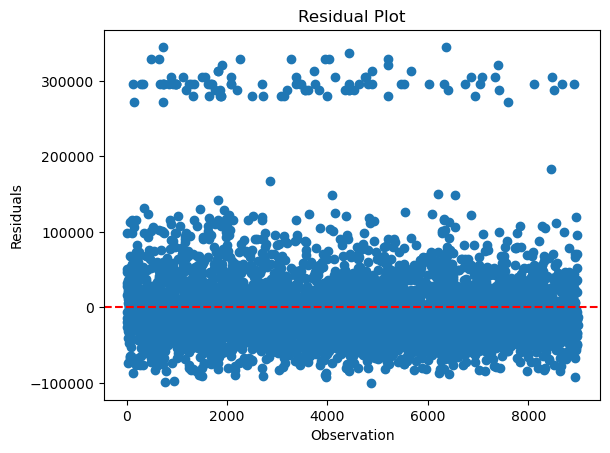

In [48]:
# Please write your executable code here
fig, ax = plt.subplots()
ax.plot(results.resid, 'o')
ax.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Observation')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show(results)

### Exercise 6: Regression with Binary Independent Variable

#### Understanding Binary Regressors

When the independent variable is binary (0/1), the interpretation changes:
- The intercept = mean of Y when X = 0
- The slope = difference in means between X = 1 and X = 0
- This is equivalent to a two-sample t-test!

15. Write the code for fitting a regression model with `educ` as the dependent variable and `male` as the independent variable using formula notation. Print the output of the regression model.

**Model:** $\text{educ}_i = \beta_0 + \beta_1 \text{male}_i + \epsilon_i$

In [49]:
# Please write your executable code here
# One-line code
model=smf.ols('educ ~ male', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   educ   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     116.1
Date:                Sat, 07 Feb 2026   Prob (F-statistic):           6.72e-27
Time:                        15:44:13   Log-Likelihood:                -19262.
No. Observations:                8151   AIC:                         3.853e+04
Df Residuals:                    8149   BIC:                         3.854e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.3441      0.041    328.104      0.0

16. Interpret the results.
 
**What to explain:**
1. **Intercept:** Mean education for females (male = 0)
2. **Coefficient on male:** Difference in education between males and females
3. **Statistical significance:** Is the gender gap significant?
4. **R-squared:** How much of education variation is explained by gender?

17. Write the coode for fitting a regression model with `annual income` as the dependent variable and `male` as the independent variable using formula notation. Print the output of the regression model.

**Model:** $\text{annual\_income}_i = \beta_0 + \beta_1 \text{male}_i + \epsilon_i$

In [50]:
# Please write your executable code here
# One-line code
model1=smf.ols('annual_income ~ male', data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:          annual_income   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     145.2
Date:                Sat, 07 Feb 2026   Prob (F-statistic):           5.20e-33
Time:                        16:01:26   Log-Likelihood:                -64496.
No. Observations:                5201   AIC:                         1.290e+05
Df Residuals:                    5199   BIC:                         1.290e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5.296e+04   1159.095     45.691      0.0

18. Interpret the results, including coefficients, statistical significance and $R^2$ 

---
# Submission Checklist

Before submitting, make sure:

- [ ] All code cells run without errors
- [ ] Graphs are displayed and labeled
- [ ] File is named correctly: `ECN310_ProblemSet3_LastName_FirstName.ipynb`

**What to submit on Canvas:**
Your completed Jupyter notebook (`.ipynb` file)
- Click on the File menu in the top left.
- Hover over Download as.
- Click Notebook (.ipynb).

**Good luck!**

*Remember: The goal is not just to get the right numbers, but to understand what they mean and communicate that understanding clearly. Focus on interpretation and insight, not just computation.*